In [10]:
import numpy as np
import matplotlib.pyplot as plt


# limiting floating-point numbers to 2 decimal places and turning off scientific notation.
np.set_printoptions(precision=2, suppress=True)

## Helper functions for visualization.
  >(Don't stress much over this code cell as I've used AI to generate this, with practice, anyone can write this level of code for visualization)

In [11]:
# === PICTURE HELPERS — run this cell, then ignore it ===============
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]

def _axes(title, xlabel, ylabel, size=(5, 5)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def _fit(ax, points):
    xs = [0] + [p[0] for p in points]; ys = [0] + [p[1] for p in points]
    px = (max(xs) - min(xs)) * 0.35 + 0.4; py = (max(ys) - min(ys)) * 0.25 + 0.4
    ax.set_xlim(min(xs) - 0.15 * px, max(xs) + px)
    ax.set_ylim(min(ys) - 0.25 * py, max(ys) + py)

def draw_vectors(title, axes=("feature 1", "feature 2"), **vectors):
    "Draw 2-D vectors as arrows from the origin."
    ax = _axes(title, axes[0], axes[1])
    pts = []
    for i, (name, v) in enumerate(vectors.items()):
        v = np.asarray(v, dtype=float); pts.append(v)
        c = COLORS[i % 3]
        # later arrows are drawn thinner, so overlapping ones stay visible
        ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
                  color=c, width=0.014 - 0.004 * i)
        ax.annotate(name, v, xytext=(8, 8 if i % 2 == 0 else -14),
                    textcoords="offset points", color=c, fontsize=9)
    ax.axhline(0, color="#cccccc", lw=1); ax.axvline(0, color="#cccccc", lw=1)
    _fit(ax, pts); plt.show()

def draw_distance(a, b, name_a="a", name_b="b"):
    "Two points and the arrow between them."
    a = np.asarray(a, float); b = np.asarray(b, float)
    ax = _axes("distance = the length of the arrow from a to b", "feature 1", "feature 2")
    ax.scatter(*a, s=110, color=COLORS[0], zorder=3)
    ax.scatter(*b, s=110, color=COLORS[1], zorder=3)
    ax.quiver(a[0], a[1], *(b - a), angles="xy", scale_units="xy", scale=1,
              color=COLORS[2], width=0.008)
    ax.annotate(name_a, a, xytext=(-20, 8), textcoords="offset points", color=COLORS[0])
    ax.annotate(name_b, b, xytext=(10, 6), textcoords="offset points", color=COLORS[1])
    ax.annotate(f"length = {np.linalg.norm(b - a):.2f}", (a + b) / 2,
                xytext=(10, 8), textcoords="offset points", color=COLORS[2], fontsize=9)
    _fit(ax, [a, b]); plt.show()

def draw_points(x, y, names, xlabel, ylabel, title):
    "A labelled scatter plot."
    ax = _axes(title, xlabel, ylabel)
    ax.scatter(x, y, s=110, color=COLORS[0], zorder=3)
    for xi, yi, n in zip(x, y, names):
        ax.annotate(n, (xi, yi), xytext=(10, 6), textcoords="offset points", fontsize=9)
    ax.margins(0.25); plt.show()

def show_table(matrix, names, title=""):
    "Print a square matrix with row and column labels."
    if title: print(title)
    print("        " + "".join(f"{n:>9}" for n in names))
    for n, row in zip(names, matrix):
        print(f"{n:>7} " + "".join(f"{v:9.2f}" for v in row))

print("Picture helpers ready.")

Picture helpers ready.


## Vectors and Matrices
- scalar - one number. (0d)
- vector - list of numbers (1d)
- matrix - multiple vectors combined (2d)
- tensor - (n-d)

In [12]:
cust_age = 35 # scalar

customer= np.array([35,55, 12]) # vector
customers = np.array([
    [34, 55, 12],
    [28, 42,  5],
    [45, 68, 20],
])

print("One customer:", customer)
print("Dataset:\n", customers)
print("Shape (rows, columns):", customers.shape)

One customer: [35 55 12]
Dataset:
 [[34 55 12]
 [28 42  5]
 [45 68 20]]
Shape (rows, columns): (3, 3)


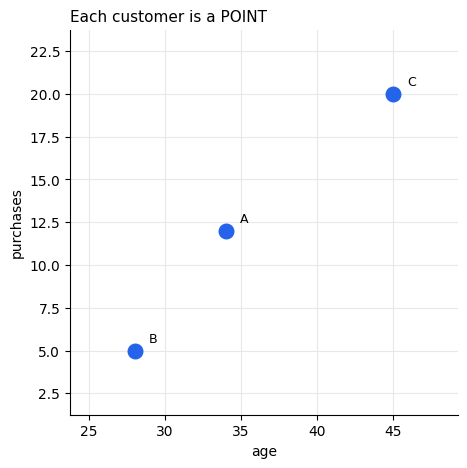

In [13]:
draw_points(x=customers[:, 0],          # column 0 = age
            y=customers[:, 2],          # column 2 = purchases
            names=["A", "B", "C"],
            xlabel="age", ylabel="purchases",
            title="Each customer is a POINT")

## Applicant loan
*  1 [age, income, loan, tenure, coapplicant, education, job]
*  2 [age, income, loan, tenure, coapplicant, education, job]
*  3 [age, income, loan, tenure, coapplicant, education, job] ...and so on

In [14]:
last_month = np.array([2, 5, 1])
this_month = np.array([3, 1, 4])

print("total sales:  ", last_month + this_month)
print("change:   ", this_month - last_month)
print("doubled:  ", 2 * this_month)

total sales:   [5 6 5]
change:    [ 1 -4  3]
doubled:   [6 2 8]


In [15]:
# adding vectors with different shape/order will lead to errors
# example

# a = np.array([3, 5, 1])
# b = np.array([1, 4])

# print(a+b)

## Dot Product
dot(a, b)

**Meaning 1 :** weighted sum of (weights and feature/input = prediction)

a1.b1 + a2.b2 + ...


In [16]:
a = np.array([2, 5, 1])
b = np.array([3, 1, 4])

# 3 different methods of dot product using numpy - all give the same output
print( np.dot(a, b) )
print( a.dot(b) )
print( a @ b )

15
15
15


In [17]:
# dot product example of linear regression w.T x + b

features = np.array([35, 55, 12])           # input by the user
weights = np.array([0.1, 0.5, 2.0])         # learnd by model/ML

predict = features @ weights
print("score:", predict)

score: 55.0


In [19]:
# Email spam score example

#                    free  meeting  winner  report
# email  = np.array([ 3,     0,      2,      0])     # this email
email  = np.array([ 1,     5,      0,      3])     # this email
weights=np.array([ 1.2,  -0.9,    1.8,   -1.1])   # learned

score  = email@weights
print("spam score:", score.round(2))
print("result:", "SPAM" if score > 0 else "not spam")

spam score: -6.6
result: not spam


## Dot Product
**Meaning 2:** how 2 vectors are alinged (same direction or not)

dot(a,b) = |a|.|b|.cos(angle)

- represents similarity of 2 vectors.
- popularly used in cosine similarity.

In [25]:
# example - similariy in prefernece between groceries and tech products

#               [electronics spend, groceries spend]

tech = np.array([            4    ,        1])
tech2 = np.array([           5    ,        1])
groceries = np.array([      -2    ,       4])
groceries2 = np.array([      -1    ,       3])

print("tech @ tech2 :", tech.dot(tech2)) # similar taste.
print("tech @ groceries :", tech.dot(groceries)) # opposite taste

tech @ tech2 : 21
tech @ groceries : -4


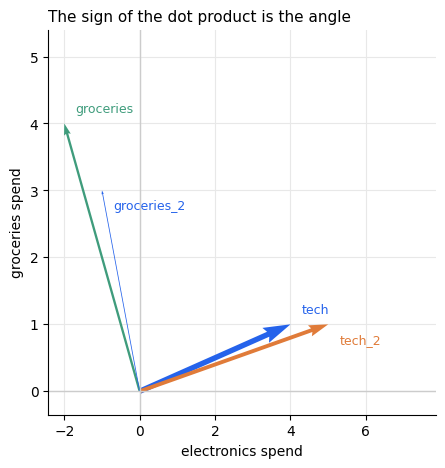

In [26]:
draw_vectors("The sign of the dot product is the angle",
             axes=("electronics spend", "groceries spend"),
             tech=tech, tech_2=tech2, groceries=groceries, groceries_2 = groceries2)

Puzzle:
1. Make two vectors of length 4: `week1` and `week2`
2. Add them to get `total`
3. Make a `weights` vector of length 4 and compute `total @ weights`

In [27]:
week1 = np.array([3, 1, 5, 0])
week2 = np.array([6, 2, 4, 1])
total = week1 + week2

weights = np.array([0.1, -0.4, 0.6, -1.0])
predict = weights @ total
print(predict)

4.1


## Norm of a vector

In [28]:
v = np.array([3, 4])
print("length:", np.linalg.norm(v))

length: 5.0


In [29]:
print(total)
print("length:", np.linalg.norm(total)) # norm of the total vector

[9 3 9 1]
length: 13.114877048604


In [32]:
a = np.array([1, 3])
b = np.array([4, 1])
c = b-a
print("b-a :", c)
print("length:", np.linalg.norm(b-a))

b-a : [ 3 -2]
length: 3.605551275463989


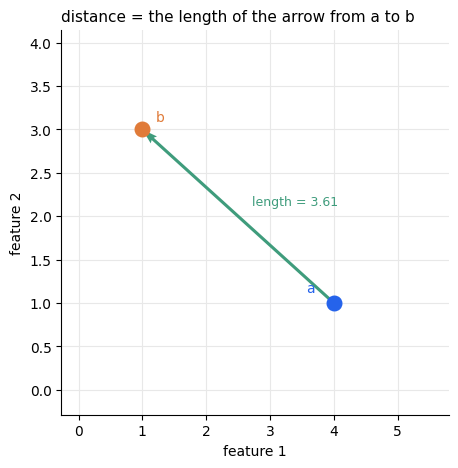

In [33]:
# Norm is the same as the distance between 2 vectors

draw_distance(b, a)

## Cosine similarity
 - dot product divided by the norm of vectors.
 - cosine angle between 2 vectors.
 - only looks at the direction (not the magnitude)



```
 a.b = |a| . |b| cos(angle)
 cos(angle) = a.b / |a|.|b|
```

range : [-1, +1]

In [34]:
#                          laptop  cooking-recipees
short_tech = np.array([        3,     1])
long_tech  = np.array([        30,     10])
cooking    = np.array([        0,     5])

In [35]:
def cosine(a, b):
  return a@b/(np.linalg.norm(a) * np.linalg.norm(b))

In [37]:
# Similarity bw short tech and long tech
cosine (short_tech, long_tech)

np.float64(1.0)

In [40]:
# Similariy bw short tech and cooking
cosine(short_tech, cooking)

np.float64(0.3162277660168379)

## Unit vector
* a vector that has a magnitude (length) of exactly \(1\).
* It shows the direction of a vector without changing its size.
* The direction does not change when you convert a vector into a unit vector.

In [42]:
def unit(vector):
  return vector / np.linalg.norm(vector)

In [43]:
v = np.array([3, 4])
v_unit = unit(v)
print(v)
print(v_unit)

[3 4]
[0.6 0.8]


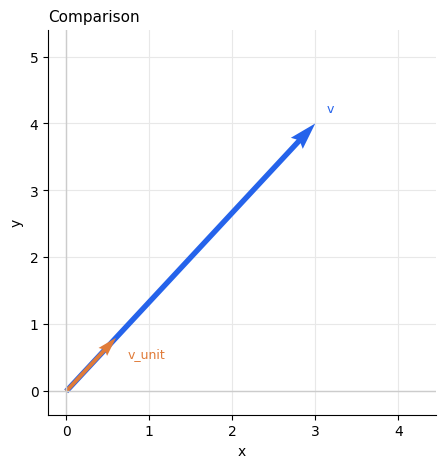

In [44]:
draw_vectors("Comparison", axes = ("x", "y"), v = v, v_unit = v_unit);

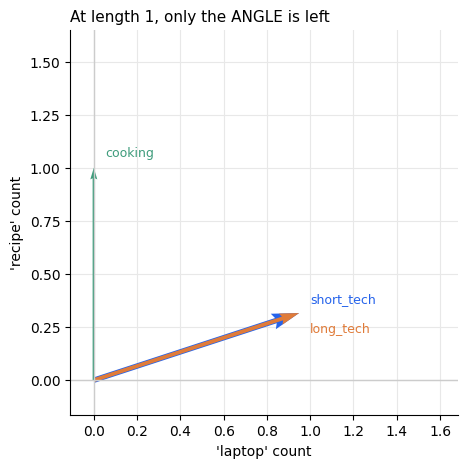

In [45]:
draw_vectors("At length 1, only the ANGLE is left",
             axes=("'laptop' count", "'recipe' count"),
             short_tech=unit(short_tech),
             long_tech=unit(long_tech),
             cooking=unit(cooking))

## Matrix Multiplication

In [48]:
A = np.random.randint(1, 10, size=(2,4))
B = np.random.randint(1, 10, (4,5))

print(A)
print(A.shape)
print(B)
print(B.shape)

[[6 7 7 2]
 [7 9 5 9]]
(2, 4)
[[6 8 5 6 2]
 [8 5 4 2 1]
 [4 6 7 5 4]
 [5 3 6 3 3]]
(4, 5)


In [51]:
# element wise multiplication - will raise error because dimensions of matrices are not matching
# print(A * B)

In [54]:
# Matrix to matrix multiplication - possible only if inner dimensions are matching

np.dot(A, B) # can also use A @ B

array([[130, 131, 119,  91,  53],
       [179, 158, 160, 112,  70]])

In [55]:
# transpose of vector / matrix
A.T

array([[6, 7],
       [7, 9],
       [7, 5],
       [2, 9]])

In [58]:
A @ A.T      # np.dot(A, A)

array([[138, 158],
       [158, 236]])

In [63]:
# model.predict(X_test)  : y_pred = X_tests @ weights

customers = np.array([
    [34, 55, 12],
    [28, 42,  5],
    [45, 68, 20],
    [39, 50,  9],
])

weights = np.array([0.1, 0.5, 2.0])

customers @ weights

array([54.9, 33.8, 78.5, 46.9])

In [64]:
# model.fit(X_train, y_train)

# Recommendation System.

In [65]:
# users, movies, ratings
# Mohit, Intersaller , 5
# Ankit , Titanic, 3

# 500 M users.
users  = ["Aisha", "Bilal", "Chen", "Divya", "Erik"]
movies = ["Fight Club", "KGF", "chand mera dil", "Musafir cafe", "Jiro dreams of shushi'"]

# movie scores given by the above mentioned users (0 means they have not watched that movie yet)
R = np.array([
    [5, 0, 1, 0, 2],     # Aisha
    [4, 5, 0, 1, 1],     # Bilal
    [0, 1, 5, 4, 2],     # Chen
    [1, 0, 4, 5, 3],     # Divya
    [1, 1, 1, 1, 5],     # Erik
])

print("shape:", R.shape, "-> 5 users (rows) x 5 movies (columns)")

shape: (5, 5) -> 5 users (rows) x 5 movies (columns)


In [66]:
# i want to convert all the vectors to unit vectors.....
R_unit = np.array([unit(user) for user in R])
R_unit

array([[0.91, 0.  , 0.18, 0.  , 0.37],
       [0.61, 0.76, 0.  , 0.15, 0.15],
       [0.  , 0.15, 0.74, 0.59, 0.29],
       [0.14, 0.  , 0.56, 0.7 , 0.42],
       [0.19, 0.19, 0.19, 0.19, 0.93]])

In [67]:
# cosine similary of every user with other users.
S = R_unit @ R_unit.T
S

array([[1.  , 0.61, 0.24, 0.38, 0.54],
       [0.61, 1.  , 0.25, 0.26, 0.42],
       [0.24, 0.25, 1.  , 0.95, 0.55],
       [0.38, 0.26, 0.95, 1.  , 0.65],
       [0.54, 0.42, 0.55, 0.65, 1.  ]])

In [68]:
show_table(S, users, "Cosine similarity between every pair of users:")

Cosine similarity between every pair of users:
            Aisha    Bilal     Chen    Divya     Erik
  Aisha      1.00     0.61     0.24     0.38     0.54
  Bilal      0.61     1.00     0.25     0.26     0.42
   Chen      0.24     0.25     1.00     0.95     0.55
  Divya      0.38     0.26     0.95     1.00     0.65
   Erik      0.54     0.42     0.55     0.65     1.00


In [72]:
# Aisha has login to netflix,
# Netflix wants to recommend a new movie to Aisha.

aisha = S[0].copy() # index 0 is aisha
aisha[0] = 0
match = np.argmax(aisha)
print("closest user to Aisha:", users[match])
R[match, 1] # recommend the movie idx 1
print("Recommende movie -", movies[1])

closest user to Aisha: Bilal
Recommende movie - KGF
